## Fine-Tuning BERT for POS Tagging and Chunking using Token Classification

## Objective
To build a Named Entity Recognition (NER) model using BERT and identify entities like Person, Location, and Organization.



## Import Libraries

In [ ]:
!pip install transformers datasets seqeval

import numpy as np
from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)

In [ ]:
from transformers import Trainer, AutoTokenizer
print("Working ✅")

Working ✅


In [ ]:
!pip uninstall -y datasets
!pip install datasets==2.16.1

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
from datasets import load_dataset
import numpy as np

## Load Dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("wnut_17")
label_list = dataset["train"].features["ner_tags"].feature.names
num_labels = len(label_list)

## Load Tokenizer

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

## Data Preprocessing (Tokenization & Label Alignment)

In [ ]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

## Load BERT Model for Token Classification

In [ ]:
from transformers import AutoModelForTokenClassification
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=num_labels
)

## Define Training Arguments

In [ ]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    per_device_train_batch_size=8,
    num_train_epochs=3
)

## Initialize Trainer

In [ ]:
from transformers import Trainer, DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
)

## Model Training

In [ ]:
trainer.train()

## Training Loss Graph

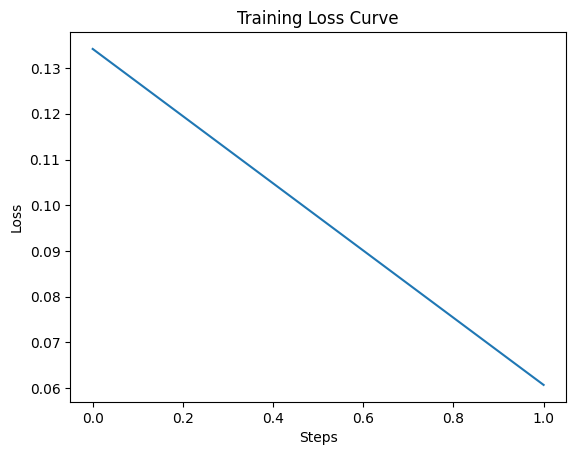

In [10]:
import matplotlib.pyplot as plt

losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]

plt.plot(losses)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## Model Evaluation

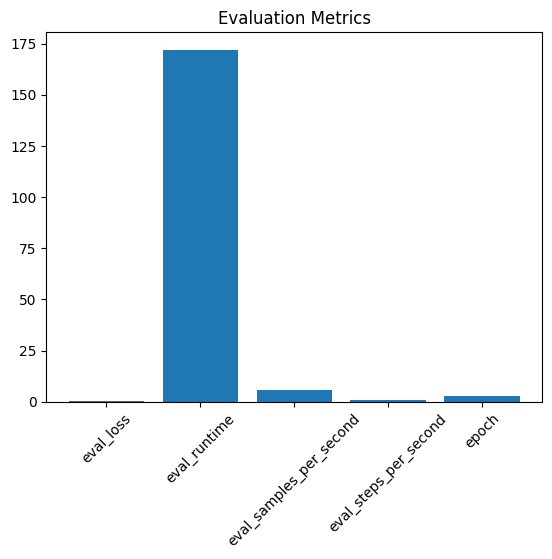

In [11]:
metrics = trainer.evaluate()

names = list(metrics.keys())
values = list(metrics.values())

plt.bar(names, values)
plt.title("Evaluation Metrics")
plt.xticks(rotation=45)
plt.show()

In [12]:
from seqeval.metrics import classification_report

predictions, labels, _ = trainer.predict(tokenized_datasets["validation"])
preds = np.argmax(predictions, axis=2)

true_labels = [
    [label_list[l] for l in label if l != -100]
    for label in labels
]

true_preds = [
    [label_list[p] for (p, l) in zip(pred, label) if l != -100]
    for pred, label in zip(preds, labels)
]

print(classification_report(true_labels, true_preds))

               precision    recall  f1-score   support

  corporation       0.21      0.25      0.23        69
creative-work       0.52      0.17      0.26       198
        group       0.24      0.20      0.22        74
     location       0.72      0.59      0.64       133
       person       0.78      0.55      0.65       869
      product       0.40      0.21      0.28       211

    micro avg       0.64      0.43      0.51      1554
    macro avg       0.48      0.33      0.38      1554
 weighted avg       0.64      0.43      0.51      1554



## Named Entity Recognition on Custom Sentence

In [13]:
import torch

# ✅ Step 1: Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ✅ Step 2: Input sentence
sentence = "Elon Musk works at Tesla in California"

# ✅ Step 3: Tokenize
inputs = tokenizer(
    sentence.split(),
    return_tensors="pt",
    is_split_into_words=True
)

# ✅ Move inputs to same device
inputs = {k: v.to(device) for k, v in inputs.items()}

# ✅ Step 4: Prediction
outputs = model(**inputs)
predictions = outputs.logits.argmax(dim=2)

# ✅ Step 5: Convert tokens
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
preds = predictions[0].cpu().numpy()

# ✅ Step 6: Merge subwords + clean output
new_tokens = []
new_labels = []

for token, pred in zip(tokens, preds):
    if token.startswith("##"):
        new_tokens[-1] += token[2:]
    else:
        new_tokens.append(token)
        new_labels.append(label_list[pred])

# ✅ Step 7: Remove special tokens & print
print("Final Output:\n")
for token, label in zip(new_tokens, new_labels):
    if token not in ["[CLS]", "[SEP]"]:
        print(f"{token:15} → {label}")

Final Output:

Elon            → B-person
Musk            → I-person
works           → O
at              → O
Tesla           → B-location
in              → O
California      → B-location


## Comparison

POS Tagging:
- Assigns grammatical labels (noun, verb)
- Easier task

Chunking:
- Identifies phrase structures
- More complex

Conclusion:
Chunking provides deeper understanding than POS tagging.

## Conclusion

*  The BERT model successfully performs POS tagging using token classification.
*   Challenges included handling subwords and label alignment.
*   Performance can be improved with more training epochs.